# Assignment 3

Deadline: 09.04.2025 12:00 CET

Liam Kane, 19-734-862, liam.kane@uzh.ch

Panagiotis Patsias, 23-720-394, panagiotis.patsias@uzh.ch

Tim Vorburger, 20-703-302, tim.vorburger@uzh.ch

Christopher Narayanan, 21-730-916, christopher.narayanan@uzh.ch

In [509]:
# Standard library imports
import os
import sys
import types

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   #<Change this path if needed>
src_path = os.path.join(project_root, 'qpmwp-course/src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import load_data_msci
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.optimization import MeanVariance
from backtesting.backtest_item_builder_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder_functions import (
    bibfn_selection_data_random,
    bibfn_return_series,
    bibfn_budget_constraint,
    bibfn_box_constraints,
)
from backtesting.portfolio import floating_weights
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

### Data load

In [510]:
N = 24
data = load_data_msci(path = '../data/', n = N)  #<Change the path if needed>

### Prepare backtest service

In [511]:
# Define rebalancing dates
n_days = 21 * 3
start_date = '2010-01-01'
dates = data['return_series'].index
rebdates = dates[dates > start_date][::n_days].strftime('%Y-%m-%d').tolist()

# Define the selection item builders.
selection_item_builders = {
    'data': SelectionItemBuilder(
        bibfn = bibfn_selection_data_random,
        k = 10,
        seed = 42,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn = bibfn_return_series,
        width = 365 * 3,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn = bibfn_budget_constraint,
        budget = 1,
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn = bibfn_box_constraints,
        upper = 0.5,
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data = data,
    selection_item_builders = selection_item_builders,
    optimization_item_builders = optimization_item_builders,
    optimization = MeanVariance(
        covariance = Covariance(method = 'pearson'),
        expected_return = ExpectedReturn(method = 'geometric'),
        risk_aversion = 1,
        solver_name = 'cvxopt',
    ),
    rebdates = rebdates,
)

### Run the backtest

In [512]:
# Instantiate the backtest object and run the backtest
bt_mv = Backtest()

# Run the backtest
bt_mv.run(bs = bs)

Rebalancing date: 2010-01-04
Rebalancing date: 2010-04-01
Rebalancing date: 2010-06-29
Rebalancing date: 2010-09-24
Rebalancing date: 2010-12-22
Rebalancing date: 2011-03-21
Rebalancing date: 2011-06-16
Rebalancing date: 2011-09-13
Rebalancing date: 2011-12-09
Rebalancing date: 2012-03-07
Rebalancing date: 2012-06-04
Rebalancing date: 2012-08-30
Rebalancing date: 2012-11-27
Rebalancing date: 2013-02-22
Rebalancing date: 2013-05-22
Rebalancing date: 2013-08-19
Rebalancing date: 2013-11-14
Rebalancing date: 2014-02-11
Rebalancing date: 2014-05-09
Rebalancing date: 2014-08-06
Rebalancing date: 2014-11-03
Rebalancing date: 2015-01-29
Rebalancing date: 2015-04-28
Rebalancing date: 2015-07-24
Rebalancing date: 2015-10-21
Rebalancing date: 2016-01-18
Rebalancing date: 2016-04-14
Rebalancing date: 2016-07-12
Rebalancing date: 2016-10-07
Rebalancing date: 2017-01-04
Rebalancing date: 2017-04-03
Rebalancing date: 2017-06-29
Rebalancing date: 2017-09-26
Rebalancing date: 2017-12-22
Rebalancing da

## 1. Turnover

**(6 points)**

Complete the function `turnover`.

In [513]:

def turnover(self, return_series: pd.DataFrame, rescale: bool=True):

    dates = self.get_rebalancing_dates()
    to = {}
    to[dates[0]] = float(1)
    for rebalancing_date in dates[1:]:

        previous_portfolio = self.get_previous_portfolio(rebalancing_date)
        current_portfolio = self.get_portfolio(rebalancing_date)
        
        if current_portfolio.rebalancing_date is None or previous_portfolio.rebalancing_date is None:
            raise ValueError('Portfolios must have a rebalancing date')

        if current_portfolio.rebalancing_date < previous_portfolio.rebalancing_date:
            raise ValueError('The previous portfolio must be older than the current portfolio')

        # Get the union of the ids of the weights in both portfolios (previous and current)
        union_curr_prev_weight_ids = set(current_portfolio.weights.keys()).union(set(previous_portfolio.weights.keys()))

        # Extend the weights of the previous portfolio to the the union of ids in both portfolios by adding zeros
        previous_portfolio.weights = {key: previous_portfolio.weights.get(key, 0) for key in union_curr_prev_weight_ids}

        # Float the weights of the previous portfolio according to the price drifts in the market 
        # until the current rebalancing date
        # Hint: use function floating_weights from module portfolio.py
        floating_weights(return_series, previous_portfolio.weights, dates[0], rebalancing_date, rescale=rescale)

        # Extract the weights of the current portfolio
        curr_weights = current_portfolio.get_weights_series()

        # Calculate the turnover
        to[rebalancing_date] = np.sum(np.abs(curr_weights - previous_portfolio.get_weights_series()))

    return pd.Series(to)


2: Simulation

(6 points)

Complete the function `simulate`.

In [514]:
def simulate(self,
                return_series: pd.DataFrame,
                fc: float = 0,
                vc: float = 0,
                n_days_per_year: int = 252) -> pd.Series:

    rebdates = self.get_rebalancing_dates()
    ret_list = []
    for rebdate in rebdates:
        next_rebdate = (
            rebdates[rebdates.index(rebdate) + 1]
            if rebdate < rebdates[-1]
            else return_series.index[-1]
        )

        portfolio = self.get_portfolio(rebdate)
        w_float = portfolio.float_weights(
            return_series=return_series,
            end_date=next_rebdate,
            rescale=False # Notice that rescale is hardcoded to False.
        )
        level = w_float.sum(axis=1)
        ret_tmp = level.pct_change(1)
        ret_list.append(ret_tmp)

    portf_ret = pd.concat(ret_list).dropna()

    if vc != 0:
        # Calculate turnover
        to = self.turnover(return_series=return_series,
                           rescale=False)
        # Calculate variable cost (vc) as a fraction of turnover and
        # subtract the variable cost from the returns at each rebalancing date
        
        for rebdate in rebdates:
            if rebdate in portf_ret.index:
                variable_cost = vc * to.loc[rebdate]
                portf_ret.loc[rebdate] -= variable_cost

    if fc != 0:
        # Calculate number of days between returns
        # Calculate daily fixed cost based on the annual fixed cost (fc),
        # the number of days between two rebalancings and the number of days per year.
        # Subtract the daily fixed cost from the daily returns

        daily_fixed_cost = fc / n_days_per_year
        portf_ret = portf_ret - daily_fixed_cost

        print("========================")

        for i in range(len(rebdates) - 1):
            start_date = rebdates[i]
            end_date = rebdates[i + 1]

            period_index = portf_ret.loc[start_date:end_date].index
            days_in_period = len(period_index)

            fc_per_period = fc * (days_in_period / n_days_per_year)

            daily_fc_for_period = fc_per_period / days_in_period

            portf_ret.loc[start_date:end_date] -= daily_fc_for_period

    print(portf_ret)
    return portf_ret

Overwrite the turnover and the simulation methods of the current strategy object.

In [515]:
# Overwrite the turnover method of the strategy object
bt_mv.strategy.turnover = types.MethodType(turnover, bt_mv.strategy)

# Overwrite the simulate method of the strategy object
bt_mv.strategy.simulate = types.MethodType(simulate, bt_mv.strategy)

Calculate and plot the turnover.

<Axes: title={'center': 'Turnover'}>

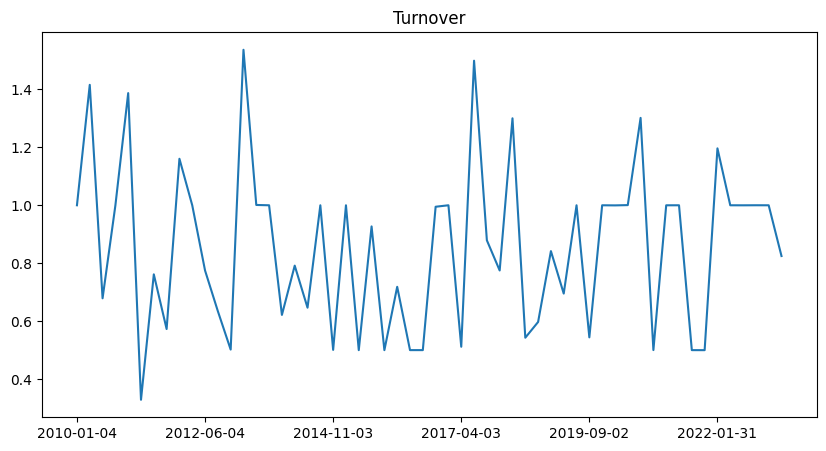

In [516]:
bt_mv.strategy.turnover(
    return_series = data['return_series'],
    rescale = True,
).plot(title = 'Turnover', figsize = (10, 5))


Simulate with different cost assumptions.

In [517]:
return_series = bs.data['return_series']

sim_mv_gross = bt_mv.strategy.simulate(return_series=return_series, fc=0, vc=0)
sim_mv_net_of_fc = bt_mv.strategy.simulate(return_series=return_series, fc=0.01, vc=0)
sim_mv_net_of_vc = bt_mv.strategy.simulate(return_series=return_series, fc=0, vc=0.002)
sim_mv_net = bt_mv.strategy.simulate(return_series=return_series, fc=0.01, vc=0.002)


Index
2010-01-05    0.005455
2010-01-06   -0.000439
2010-01-07   -0.003031
2010-01-08    0.003712
2010-01-11    0.005566
                ...   
2023-04-12    0.003083
2023-04-13    0.004226
2023-04-14    0.007601
2023-04-17    0.001501
2023-04-18   -0.000407
Length: 3466, dtype: float64
Index
2010-01-05    0.005376
2010-01-06   -0.000518
2010-01-07   -0.003110
2010-01-08    0.003632
2010-01-11    0.005486
                ...   
2023-04-12    0.003004
2023-04-13    0.004146
2023-04-14    0.007522
2023-04-17    0.001421
2023-04-18   -0.000447
Length: 3466, dtype: float64
Index
2010-01-05    0.005455
2010-01-06   -0.000439
2010-01-07   -0.003031
2010-01-08    0.003712
2010-01-11    0.005566
                ...   
2023-04-12    0.003083
2023-04-13    0.004226
2023-04-14    0.007601
2023-04-17   -0.000149
2023-04-18   -0.000407
Length: 3466, dtype: float64
Index
2010-01-05    0.005376
2010-01-06   -0.000518
2010-01-07   -0.003110
2010-01-08    0.003632
2010-01-11    0.005486
               

Plot the cumulative returns.

<Axes: xlabel='Index'>

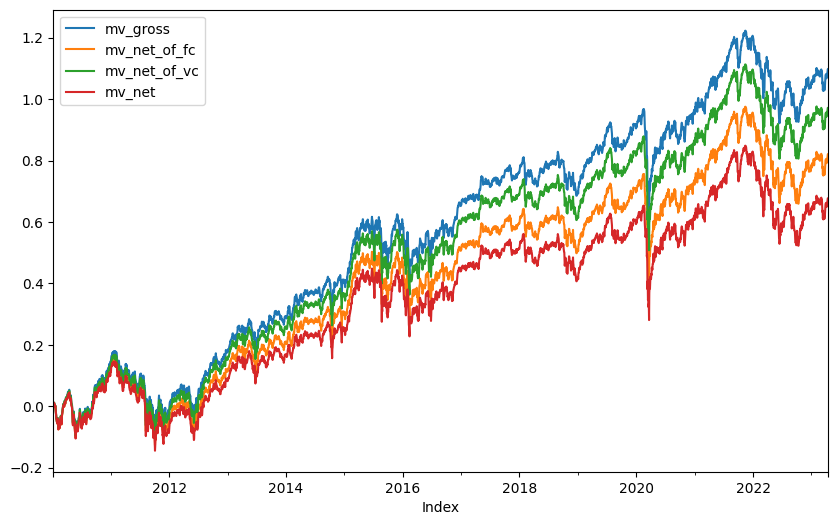

In [518]:
sim = pd.concat({
    'mv_gross': sim_mv_gross,
    'mv_net_of_fc': sim_mv_net_of_fc,
    'mv_net_of_vc': sim_mv_net_of_vc,
    'mv_net': sim_mv_net,
}, axis = 1).dropna()


np.log((1 + sim)).cumsum().plot(figsize = (10, 6))

3: Descriptive Statistics

(3 points)

Generate a table with descriptive statistics of the simulations. Include the following statistics:
- cumulative return (i.e., the return over the entire simulation period)
- annualized average returns
- annualized volatility
- sharpe ratio
- maximum drawdown

In [519]:
simulations = {
    'mv_gross': sim_mv_gross,
    'mv_net_of_fc': sim_mv_net_of_fc,
    'mv_net_of_vc': sim_mv_net_of_vc,
    'mv_net': sim_mv_net
}

metrics_table = pd.DataFrame(columns=['Cumulative Return', 'Annualized Return', 'Annualized Volatility', 'Sharpe Ratio', 'Maximum Drawdown'])

for strategy, sim in simulations.items():
    cumulative_returns = np.log((1 + sim)).cumsum().iloc[-1]
    annualized_returns = np.log(1 + sim).mean() * 252
    annualized_volatility = np.log(1 + sim).std() * np.sqrt(252)
    sharpe_ratio = annualized_returns / annualized_volatility  # assuming rf = 0
    running_drawdown = (np.log((1 + sim)).cumsum() - np.log((1 + sim)).cumsum().cummax()) / np.log((1 + sim)).cumsum().cummax()
    maximum_drawdown = running_drawdown.min()

    metrics_table.loc[strategy] = [
        cumulative_returns,
        annualized_returns,
        annualized_volatility,
        sharpe_ratio,
        maximum_drawdown
    ]

print(metrics_table)

              Cumulative Return  Annualized Return  Annualized Volatility  \
mv_gross               1.097879           0.079823               0.147613   
mv_net_of_fc           0.820763           0.059675               0.147624   
mv_net_of_vc           0.971090           0.070604               0.147687   
mv_net                 0.676255           0.049168               0.147712   

              Sharpe Ratio  Maximum Drawdown  
mv_gross          0.540758         -7.576758  
mv_net_of_fc      0.404234         -7.993823  
mv_net_of_vc      0.478068         -7.576758  
mv_net            0.332863         -7.993823  
